In [ ]:
# Setup: install/import dependencies (Colab-ready)
!pip install -q tensorflow scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import ParameterSampler, KFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import time

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)
Number of classes: 10


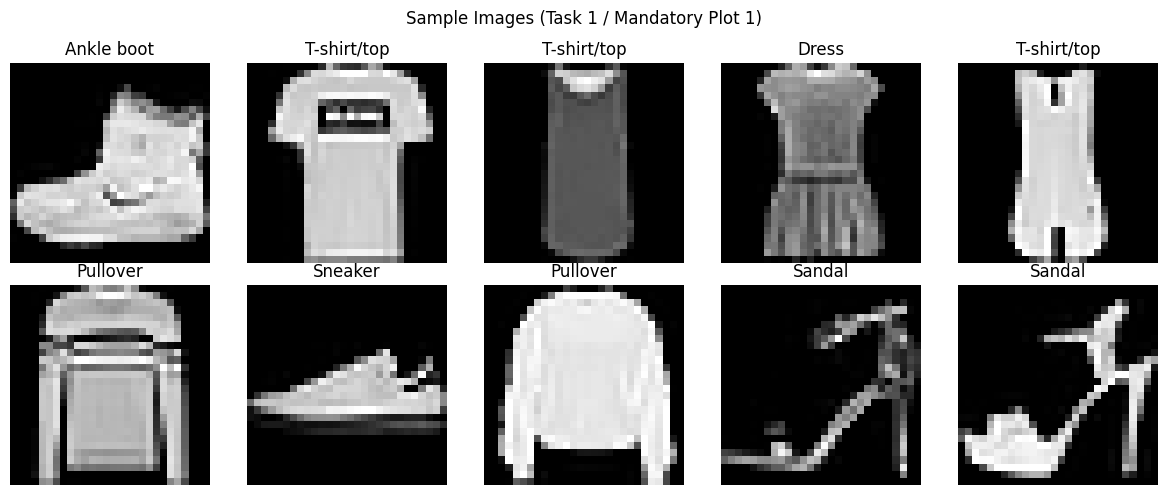

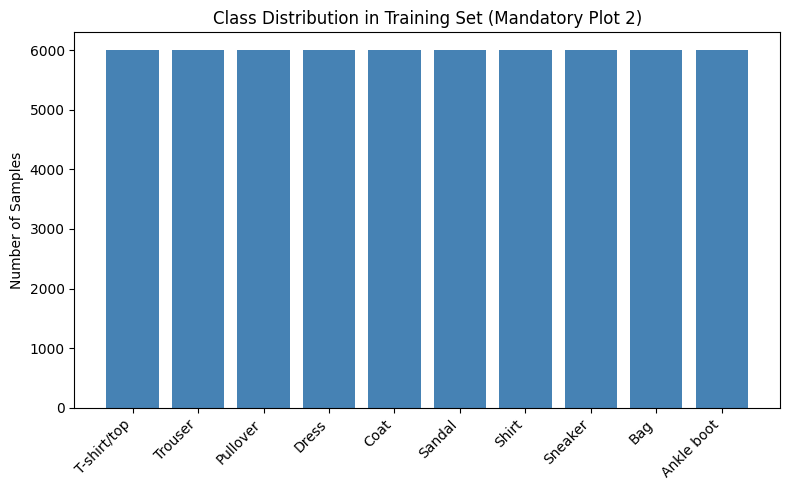

In [ ]:
# Task 1: Dataset Exploration

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)
print("Number of classes:", len(np.unique(y_train)))

# Display ten sample images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Sample Images (Task 1 / Mandatory Plot 1)")
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

# Plot class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar([class_names[u] for u in unique], counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Training Set (Mandatory Plot 2)")
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()



In [ ]:
# Task 2: Data Preprocessing

print("Before preprocessing:")
print("x_train shape:", x_train.shape, "| dtype:", x_train.dtype)
print("x_test shape:", x_test.shape)

# Normalize pixel values to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# Flatten 28x28 images into 784-length vectors
x_train_flat = x_train_norm.reshape(x_train_norm.shape[0], -1)
x_test_flat = x_test_norm.reshape(x_test_norm.shape[0], -1)

# One-hot encode labels
y_train_onehot = keras.utils.to_categorical(y_train, 10)
y_test_onehot = keras.utils.to_categorical(y_test, 10)

print("\nAfter preprocessing:")
print("x_train_flat shape:", x_train_flat.shape, "| dtype:", x_train_flat.dtype)
print("x_test_flat shape:", x_test_flat.shape)
print("y_train_onehot shape:", y_train_onehot.shape)
print("y_test_onehot shape:", y_test_onehot.shape)
print("Pixel value range:", x_train_flat.min(), "-", x_train_flat.max())



Before preprocessing:
x_train shape: (60000, 28, 28) | dtype: uint8
x_test shape: (10000, 28, 28)

After preprocessing:
x_train_flat shape: (60000, 784) | dtype: float32
x_test_flat shape: (10000, 784)
y_train_onehot shape: (60000, 10)
y_test_onehot shape: (10000, 10)
Pixel value range: 0.0 - 1.0


In [ ]:
# Task 3: Model Construction

def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Task 4: Model Training

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history = baseline_model.fit(
    x_train_flat, y_train_onehot,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)
baseline_train_time = time.time() - start_time
print(f"\nBaseline training time: {baseline_train_time:.2f} seconds")



Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.8203 - loss: 0.5028 - val_accuracy: 0.8532 - val_loss: 0.4123
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8646 - loss: 0.3731 - val_accuracy: 0.8607 - val_loss: 0.3639
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8766 - loss: 0.3359 - val_accuracy: 0.8623 - val_loss: 0.3605
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8851 - loss: 0.3103 - val_accuracy: 0.8770 - val_loss: 0.3342
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8928 - loss: 0.2895 - val_accuracy: 0.8692 - val_loss: 0.3586
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8974 - loss: 0.2752 - val_accuracy: 0.8743 - val_loss: 0.3473
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9019 - loss: 0.2615 - val_accuracy: 0.8703 - val_loss: 0.3776
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9064 - loss: 0.2490

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Baseline Test Accuracy:  0.8796
Baseline Precision:      0.8797
Baseline Recall:         0.8796
Baseline F1-score:       0.8786

Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.81      0.86      0.83      1000
     Trouser       1.00      0.94      0.97      1000
    Pullover       0.78      0.80      0.79      1000
       Dress       0.84      0.93      0.88      1000
        Coat       0.78      0.81      0.79      1000
      Sandal       0.96      0.97      0.96      1000
       Shirt       0.76      0.63      0.69      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.96      0.97      0.96      1000
  Ankle boot       0.97      0.94      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



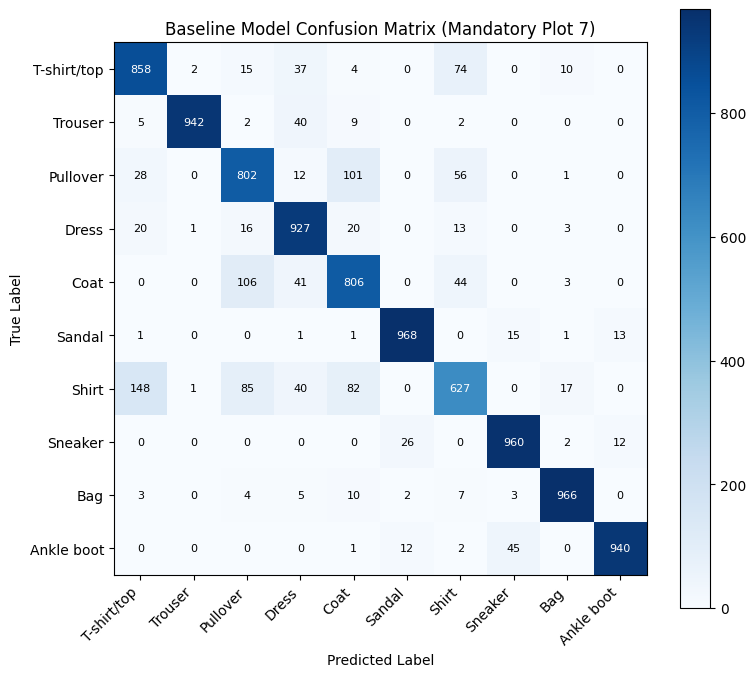

In [ ]:
# Task 5: Model Evaluation

y_pred_probs = baseline_model.predict(x_test_flat)
y_pred = np.argmax(y_pred_probs, axis=1)

baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_precision = precision_score(y_test, y_pred, average='weighted')
baseline_recall = recall_score(y_test, y_pred, average='weighted')
baseline_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Baseline Test Accuracy:  {baseline_accuracy:.4f}")
print(f"Baseline Precision:      {baseline_precision:.4f}")
print(f"Baseline Recall:         {baseline_recall:.4f}")
print(f"Baseline F1-score:       {baseline_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

baseline_cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 7))
plt.imshow(baseline_cm, cmap='Blues')
plt.title("Baseline Model Confusion Matrix (Mandatory Plot 7)")
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)
for i in range(10):
    for j in range(10):
        plt.text(j, i, baseline_cm[i, j], ha='center', va='center',
                  color='white' if baseline_cm[i, j] > baseline_cm.max() / 2 else 'black', fontsize=8)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()



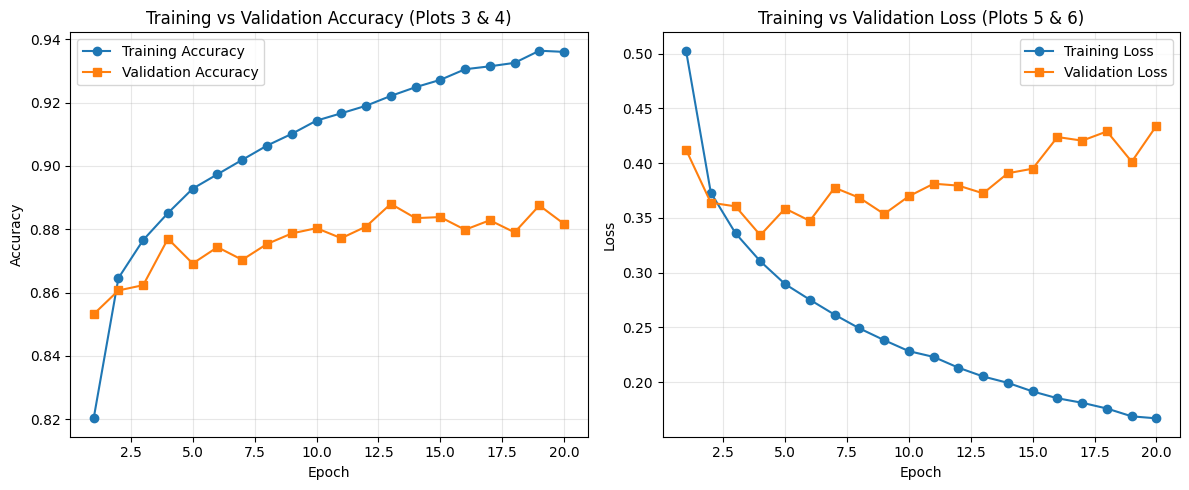

In [ ]:
# Training/Validation Accuracy vs Epoch, Training/Validation Loss vs Epoch

epochs_range = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy (Plots 3 & 4)')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Training Loss', marker='o')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Plots 5 & 6)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_loss_curves.png', dpi=150)
plt.show()



In [ ]:
# Tasks 1-2: Baseline model builder function + hyperparameter search space definition

def build_tunable_model(hidden_layers=2, hidden_neurons=64, learning_rate=0.001,
                         optimizer_name='adam', activation='relu', dropout_rate=0.0):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))

    if optimizer_name == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

param_distributions = {
    'hidden_layers': [1, 2, 3],
    'hidden_neurons': [32, 64, 128, 256],
    'learning_rate': [0.1, 0.01, 0.001],
    'optimizer_name': ['sgd', 'adam', 'rmsprop'],
    'activation': ['relu', 'tanh', 'sigmoid'],
    'dropout_rate': [0.0, 0.2, 0.5],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
}

print("Search space defined with", np.prod([len(v) for v in param_distributions.values()]),
      "possible combinations.")



Search space defined with 11664 possible combinations.


In [ ]:
# Task 3: Perform Randomized Search using 5-fold cross-validation (manual implementation)
# Use a manageable training subset for search speed in Colab; scale up N_ITER/data as compute allows.

SEARCH_SAMPLE_SIZE = 6000   # subset of training data for the search stage
N_ITER = 20                  # number of random hyperparameter combinations to try
N_SPLITS = 5                  # 5-fold cross-validation, as required

rng_np = np.random.default_rng(42)
sample_idx = rng_np.choice(len(x_train_flat), SEARCH_SAMPLE_SIZE, replace=False)
x_search = x_train_flat[sample_idx]
y_search_int = y_train[sample_idx]                       # integer labels for stratified folds
y_search_onehot = y_train_onehot[sample_idx]              # one-hot labels for training

sampled_params = list(ParameterSampler(param_distributions, n_iter=N_ITER, random_state=42))
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

search_results = []  # list of dicts: {params, mean_cv_accuracy}

search_start = time.time()
for i, params in enumerate(sampled_params):
    fold_accuracies = []
    for fold_i, (train_idx, val_idx) in enumerate(kf.split(x_search)):
        model = build_tunable_model(
            hidden_layers=params['hidden_layers'],
            hidden_neurons=params['hidden_neurons'],
            learning_rate=params['learning_rate'],
            optimizer_name=params['optimizer_name'],
            activation=params['activation'],
            dropout_rate=params['dropout_rate'],
        )
        model.fit(
            x_search[train_idx], y_search_onehot[train_idx],
            epochs=params['epochs'],
            batch_size=params['batch_size'],
            verbose=0
        )
        val_preds = np.argmax(model.predict(x_search[val_idx], verbose=0), axis=1)
        fold_acc = accuracy_score(y_search_int[val_idx], val_preds)
        fold_accuracies.append(fold_acc)

    mean_acc = float(np.mean(fold_accuracies))
    search_results.append({'params': params, 'mean_cv_accuracy': mean_acc})
    print(f"[{i + 1}/{N_ITER}] mean CV accuracy: {mean_acc:.4f} | params: {params}")

search_time = time.time() - search_start
print(f"\nHyperparameter search completed in {search_time:.2f} seconds")



[1/20] mean CV accuracy: 0.8335 | params: {'optimizer_name': 'adam', 'learning_rate': 0.001, 'hidden_neurons': 256, 'hidden_layers': 1, 'epochs': 20, 'dropout_rate': 0.2, 'batch_size': 128, 'activation': 'tanh'}
[2/20] mean CV accuracy: 0.5897 | params: {'optimizer_name': 'rmsprop', 'learning_rate': 0.01, 'hidden_neurons': 256, 'hidden_layers': 3, 'epochs': 20, 'dropout_rate': 0.5, 'batch_size': 16, 'activation': 'relu'}
[3/20] mean CV accuracy: 0.8365 | params: {'optimizer_name': 'rmsprop', 'learning_rate': 0.001, 'hidden_neurons': 128, 'hidden_layers': 3, 'epochs': 20, 'dropout_rate': 0.2, 'batch_size': 32, 'activation': 'tanh'}
[4/20] mean CV accuracy: 0.8280 | params: {'optimizer_name': 'adam', 'learning_rate': 0.001, 'hidden_neurons': 32, 'hidden_layers': 1, 'epochs': 10, 'dropout_rate': 0.2, 'batch_size': 32, 'activation': 'tanh'}
[5/20] mean CV accuracy: 0.8313 | params: {'optimizer_name': 'adam', 'learning_rate': 0.001, 'hidden_neurons': 64, 'hidden_layers': 2, 'epochs': 30, 'd

In [ ]:
# Task 4: Record the best hyperparameter combination

best_result = max(search_results, key=lambda r: r['mean_cv_accuracy'])
best_params = best_result['params']
best_cv_score = best_result['mean_cv_accuracy']

print("Best hyperparameters found:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nBest cross-validation accuracy: {best_cv_score:.4f}")


Best hyperparameters found:
  optimizer_name: adam
  learning_rate: 0.001
  hidden_neurons: 256
  hidden_layers: 1
  epochs: 20
  dropout_rate: 0.2
  batch_size: 16
  activation: relu

Best cross-validation accuracy: 0.8418


In [ ]:
# Task 5: Retrain the model using the optimized hyperparameters on the FULL training set

optimized_model = build_tunable_model(
    hidden_layers=best_params['hidden_layers'],
    hidden_neurons=best_params['hidden_neurons'],
    learning_rate=best_params['learning_rate'],
    optimizer_name=best_params['optimizer_name'],
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
)

optimized_start = time.time()
optimized_history = optimized_model.fit(
    x_train_flat, y_train_onehot,
    validation_split=0.1,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    verbose=1
)
optimized_train_time = time.time() - optimized_start
print(f"\nOptimized model training time: {optimized_train_time:.2f} seconds")


Epoch 1/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.8160 - loss: 0.5135 - val_accuracy: 0.8540 - val_loss: 0.3936
Epoch 2/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.8556 - loss: 0.3964 - val_accuracy: 0.8615 - val_loss: 0.3741
Epoch 3/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.8662 - loss: 0.3633 - val_accuracy: 0.8700 - val_loss: 0.3560
Epoch 4/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.8738 - loss: 0.3411 - val_accuracy: 0.8713 - val_loss: 0.3551
Epoch 5/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.8794 - loss: 0.3245 - val_accuracy: 0.8765 - val_loss: 0.3463
Epoch 6/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.8847 - loss: 0.3113 - val_accuracy: 0.8767 - val_loss: 0.3459
Epoch 7/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.8888 - loss: 0.2992 - val_accuracy: 0.8758 - val_loss: 0.3456
Epoch 8/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.8913 - loss: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Optimized Test Accuracy:  0.8861
Optimized Precision:      0.8877
Optimized Recall:         0.8861
Optimized F1-score:       0.8835

Classification Report (Optimized Model):

              precision    recall  f1-score   support

 T-shirt/top       0.78      0.89      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.78      0.83      0.80      1000
       Dress       0.84      0.93      0.88      1000
        Coat       0.79      0.83      0.81      1000
      Sandal       0.98      0.97      0.97      1000
       Shirt       0.82      0.55      0.66      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.99      0.97      0.98      1000
  Ankle boot       0.96      0.97      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.88     10000
weighted avg       0.89      0.89      0.88     10000



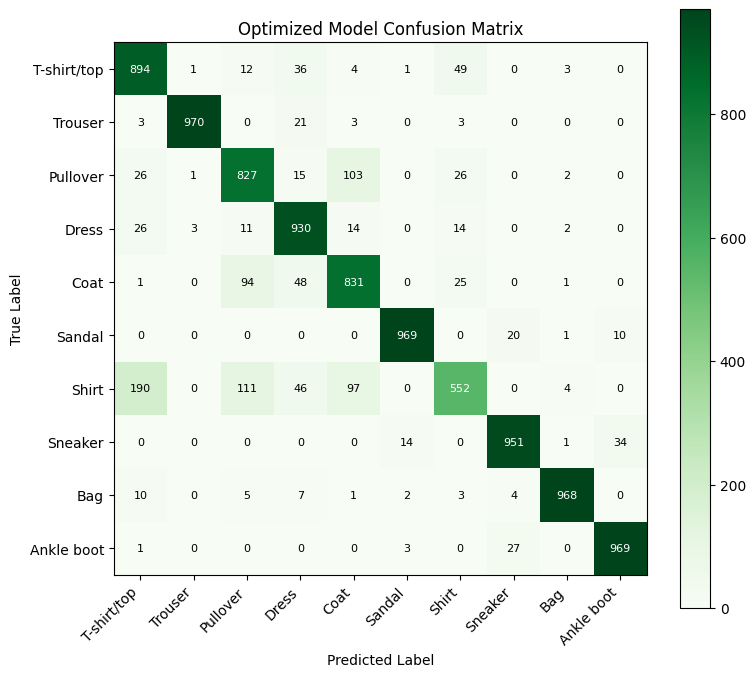

In [ ]:
# Task 6: Evaluate the optimized model on the testing dataset

y_pred_opt_probs = optimized_model.predict(x_test_flat)
y_pred_opt = np.argmax(y_pred_opt_probs, axis=1)

optimized_accuracy = accuracy_score(y_test, y_pred_opt)
optimized_precision = precision_score(y_test, y_pred_opt, average='weighted')
optimized_recall = recall_score(y_test, y_pred_opt, average='weighted')
optimized_f1 = f1_score(y_test, y_pred_opt, average='weighted')

print(f"Optimized Test Accuracy:  {optimized_accuracy:.4f}")
print(f"Optimized Precision:      {optimized_precision:.4f}")
print(f"Optimized Recall:         {optimized_recall:.4f}")
print(f"Optimized F1-score:       {optimized_f1:.4f}")

print("\nClassification Report (Optimized Model):\n")
print(classification_report(y_test, y_pred_opt, target_names=class_names))

optimized_cm = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(8, 7))
plt.imshow(optimized_cm, cmap='Greens')
plt.title("Optimized Model Confusion Matrix")
plt.colorbar()
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)
for i in range(10):
    for j in range(10):
        plt.text(j, i, optimized_cm[i, j], ha='center', va='center',
                  color='white' if optimized_cm[i, j] > optimized_cm.max() / 2 else 'black', fontsize=8)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('optimized_confusion_matrix.png', dpi=150)
plt.show()


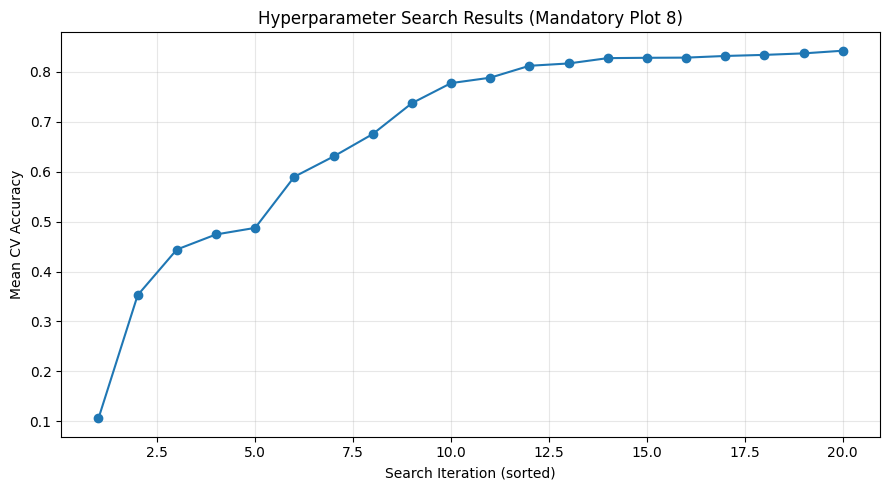

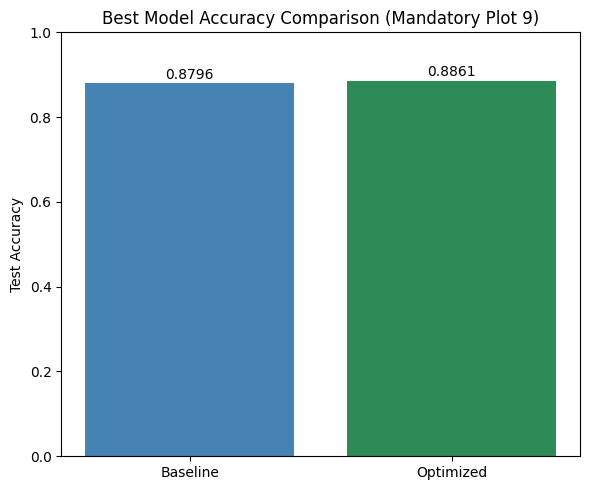

In [ ]:
# Task 7: Compare the optimized model with the baseline model (Mandatory Plots 8 & 9)

# Plot 8: Hyperparameter Search Results (CV accuracy per sampled combination)
mean_test_scores = [r['mean_cv_accuracy'] for r in search_results]

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(mean_test_scores) + 1), sorted(mean_test_scores), marker='o')
plt.xlabel('Search Iteration (sorted)')
plt.ylabel('Mean CV Accuracy')
plt.title('Hyperparameter Search Results (Mandatory Plot 8)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('hyperparameter_search_results.png', dpi=150)
plt.show()

# Plot 9: Best Model Accuracy Comparison (baseline vs optimized)
labels = ['Baseline', 'Optimized']
accuracies = [baseline_accuracy, optimized_accuracy]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, accuracies, color=['steelblue', 'seagreen'])
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
plt.title('Best Model Accuracy Comparison (Mandatory Plot 9)')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.01, f'{acc:.4f}', ha='center')
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150)
plt.show()


In [ ]:
# Results tables

print("Best Hyperparameters")
print("-" * 40)
result_table = {
    "Hidden Layers": best_params['hidden_layers'],
    "Hidden Neurons": best_params['hidden_neurons'],
    "Learning Rate": best_params['learning_rate'],
    "Batch Size": best_params['batch_size'],
    "Optimizer": best_params['optimizer_name'],
    "Activation Function": best_params['activation'],
    "Epochs": best_params['epochs'],
    "Dropout": best_params['dropout_rate'],
    "Cross-validation Accuracy": round(best_cv_score, 4),
    "Testing Accuracy": round(optimized_accuracy, 4),
}
for k, v in result_table.items():
    print(f"{k:28s}: {v}")

print("\nPerformance Comparison")
print("-" * 60)
print(f"{'Metric':15s}{'Baseline':>15s}{'Optimized':>15s}")
print(f"{'Accuracy':15s}{baseline_accuracy:15.4f}{optimized_accuracy:15.4f}")
print(f"{'Precision':15s}{baseline_precision:15.4f}{optimized_precision:15.4f}")
print(f"{'Recall':15s}{baseline_recall:15.4f}{optimized_recall:15.4f}")
print(f"{'F1-score':15s}{baseline_f1:15.4f}{optimized_f1:15.4f}")
print(f"{'Training Time(s)':15s}{baseline_train_time:15.2f}{optimized_train_time:15.2f}")


Best Hyperparameters
----------------------------------------
Hidden Layers               : 1
Hidden Neurons              : 256
Learning Rate               : 0.001
Batch Size                  : 16
Optimizer                   : adam
Activation Function         : relu
Epochs                      : 20
Dropout                     : 0.2
Cross-validation Accuracy   : 0.8418
Testing Accuracy            : 0.8861

Performance Comparison
------------------------------------------------------------
Metric                Baseline      Optimized
Accuracy                0.8796         0.8861
Precision               0.8797         0.8877
Recall                  0.8796         0.8861
F1-score                0.8786         0.8835
Training Time(s)         175.97         353.73
